# Analysis 4 — Demand Forecasting & Newsvendor Stocking

**Business question.** Forecast weekly demand well enough to set *profit-optimal* stock.

> Implementation: [`src/forecasting/forecast.py`](../src/forecasting/forecast.py).

## Step 1 — Global XGBoost vs a moving-average baseline
1-week-ahead, top-100 SKUs, 12-week holdout. Metrics in **real units (MAE/RMSE)** plus WAPE; MAPE avoided (zero-demand weeks).

In [1]:
from src.forecasting.forecast import main
main()

WAPE  baseline-MA=0.594  XGBoost=0.620
MAE   baseline=216  XGBoost=226 units
Per-SKU: XGB beats MA on 61% of SKUs (median WAPE 0.50 vs 0.51)
Newsvendor: margin 35%, holding 25% -> critical ratio 0.68 -> order = forecast + 0.48*sigma


**Honest finding:** the simple moving average wins the *aggregate* WAPE, but XGBoost wins **61% of individual SKUs** — so the senior recommendation is a **hybrid** (ML for the typical SKU, robust MA for the few high-volume volatile ones), not a trophy model.

## Step 2 — Forecast vs actual (top SKUs)

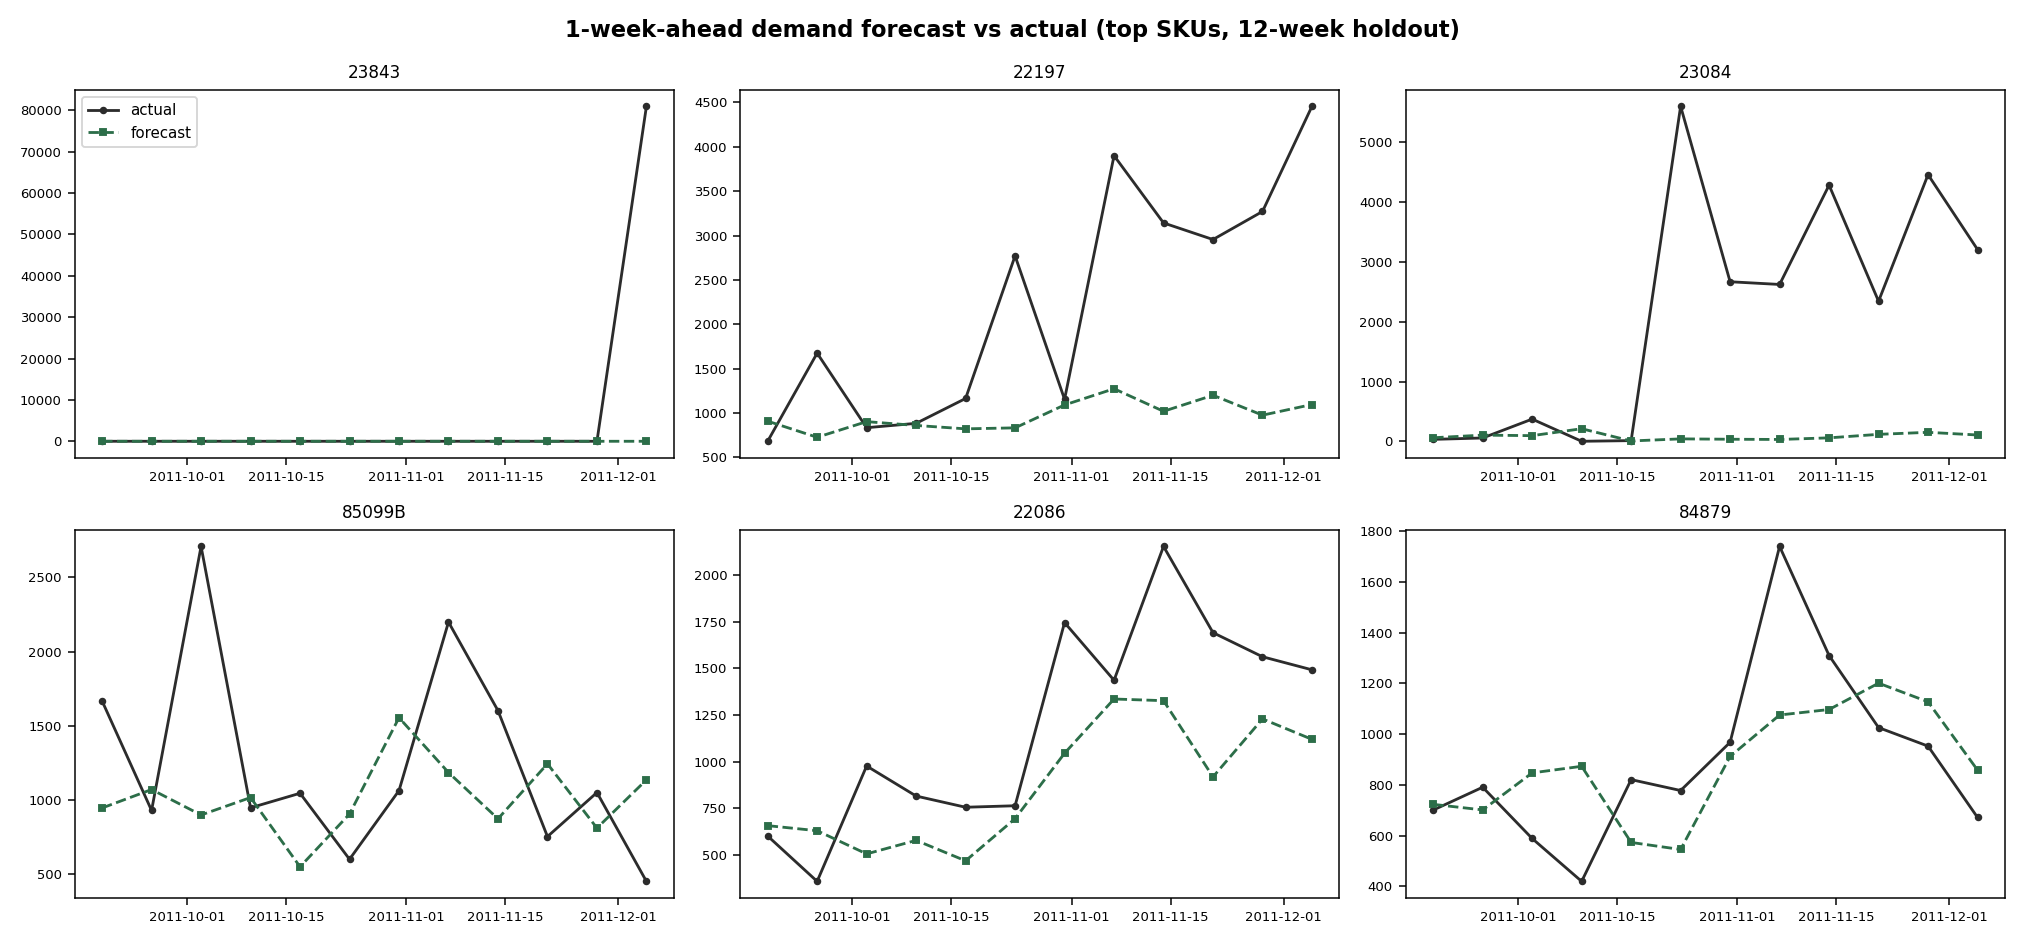

In [2]:
from IPython.display import Image
Image("../reports/figures/forecast_top_skus.png")

## Step 3 — Forecast → profit decision (newsvendor)
Critical ratio 0.68 (68% service level) → deliberately stock *above* the forecast to protect availability and recover lost-sales margin. For perishables (full write-off) the ratio falls.